In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from itertools import product
import pathlib as pth

from minigrad.tensor import Tensor
from minigrad.nn import Sequential, Linear, Perceptron, Sigmoid, Softmax
from minigrad.nn.losses import categorical_cross_entropy
from minigrad.optim import GD, SGD

In [2]:
# Specify the path to our CSV files
data_dir = pth.Path('data')
train_path = data_dir / 'fashion-mnist_train.csv'
test_path = data_dir / 'fashion-mnist_test.csv'

# 1. Load data via pandas
print("Loading data...")
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# In these CSVs, the first column is named 'label' (the correct answer from 0 to 9),
# and the remaining 784 columns are the image pixels (28x28).

# 2. Separate labels (y) from features/pixels (X)
y_train_raw = df_train['label'].values
X_train_raw = df_train.drop('label', axis=1).values

y_test_raw = df_test['label'].values
X_test_raw = df_test.drop('label', axis=1).values

# 3. Normalization (Task point 2)
# Pixels have values from 0 to 255. Neural networks struggle with such large numbers.
# Divide by 255.0 so that all values are in the range from 0.0 to 1.0.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# 4. One-Hot Encoding for labels
# Our categorical_cross_entropy loss function expects One-Hot format.
# For example, class 3 will turn into [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train = np.eye(num_classes)[y_train_raw]
y_test = np.eye(num_classes)[y_test_raw]

print("\nPreparation complete!")
print("X_train shape:", X_train.shape) # Should be (60000, 784)
print("y_train shape:", y_train.shape) # Should be (60000, 10)
print("X_test shape:", X_test.shape)   # Should be (10000, 784)
print("y_test shape:", y_test.shape)   # Should be (10000, 10)

Loading data...

Preparation complete!
X_train shape: (60000, 784)
y_train shape: (60000, 10)
X_test shape: (10000, 784)
y_test shape: (10000, 10)


In [3]:
# ==========================================
# Evaluation Metrics and Validation Function
# ==========================================

def calculate_accuracy(y_pred: np.ndarray, y_true_raw: np.ndarray) -> float:
    """
    Calculate accuracy given raw probabilities and raw target labels.
    """
    # Find the index of the highest probability class (0-9)
    predictions = np.argmax(y_pred, axis=1)
    # Compare with raw labels and compute the mean match rate
    return float(np.mean(predictions == y_true_raw))

def evaluate_model(model, X: np.ndarray, y_onehot: np.ndarray, y_raw: np.ndarray, loss_fn, batch_size: int = 32):
    """
    Evaluate the model on a dataset without updating weights (no backprop).
    """
    n_samples = X.shape[0]
    total_loss = 0.0
    all_preds = []

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        
        # requires_grad=False because we don't need gradients for evaluation
        x_batch = Tensor(X[start:end], requires_grad=False)
        y_batch = Tensor(y_onehot[start:end], requires_grad=False)

        # Forward pass only
        y_pred_tensor = model(x_batch)
        loss = loss_fn(y_pred_tensor, y_batch)

        total_loss += loss.item()
        all_preds.append(y_pred_tensor.data)

    # Calculate average loss
    avg_loss = total_loss / (n_samples / batch_size)
    
    # Concatenate all batch predictions to calculate overall accuracy
    full_preds = np.vstack(all_preds)
    accuracy = calculate_accuracy(full_preds, y_raw)

    return avg_loss, accuracy

In [ ]:
# ==========================================
# Model Definition and Training Loop
# ==========================================

from minigrad.nn import Sequential, Linear, ReLU, Softmax
from minigrad.nn.losses import categorical_cross_entropy
from minigrad.optim import SGD
from minigrad.utils.training import train_epoch

# Define base model (Task point 4: one hidden layer and softmax)
# 784 inputs (28x28 pixels) -> 128 hidden neurons -> 10 output classes
model = Sequential(
    Linear(784, 128),
    ReLU(),
    Linear(128, 10),
    Softmax()
)

# Task point 10: Hyperparameter for learning rate
learning_rate = 0.1
optimizer = SGD(model.parameters(), lr=learning_rate)

epochs = 15
batch_size = 64

# Dictionaries to store metrics for plotting (Task point 9)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Starting training...")
for epoch in range(epochs):
    # 1. Train for one epoch (updates weights)
    train_loss = train_epoch(model, X_train, y_train, categorical_cross_entropy, optimizer, batch_size)

    # 2. Evaluate on train set to get accuracy
    _, train_acc = evaluate_model(model, X_train, y_train, y_train_raw, categorical_cross_entropy, batch_size)

    # 3. Evaluate on validation (test) set
    val_loss, val_acc = evaluate_model(model, X_test, y_test, y_test_raw, categorical_cross_entropy, batch_size)

    # 4. Save metrics for plotting later
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Starting training...
Epoch 01/15 | Train Loss: 0.5836 | Train Acc: 0.8327 | Val Loss: 0.4760 | Val Acc: 0.8323
Epoch 02/15 | Train Loss: 0.4284 | Train Acc: 0.8543 | Val Loss: 0.4160 | Val Acc: 0.8534
Epoch 03/15 | Train Loss: 0.3865 | Train Acc: 0.8621 | Val Loss: 0.4012 | Val Acc: 0.8605
Epoch 04/15 | Train Loss: 0.3626 | Train Acc: 0.8705 | Val Loss: 0.3829 | Val Acc: 0.8634
Epoch 05/15 | Train Loss: 0.3425 | Train Acc: 0.8639 | Val Loss: 0.3805 | Val Acc: 0.8550
Epoch 06/15 | Train Loss: 0.3275 | Train Acc: 0.8818 | Val Loss: 0.3561 | Val Acc: 0.8718
Epoch 07/15 | Train Loss: 0.3154 | Train Acc: 0.8785 | Val Loss: 0.3671 | Val Acc: 0.8656
Epoch 08/15 | Train Loss: 0.3042 | Train Acc: 0.8921 | Val Loss: 0.3464 | Val Acc: 0.8781
Epoch 09/15 | Train Loss: 0.2965 | Train Acc: 0.9029 | Val Loss: 0.3160 | Val Acc: 0.8885
Epoch 10/15 | Train Loss: 0.2879 | Train Acc: 0.8666 | Val Loss: 0.3875 | Val Acc: 0.8520
Epoch 11/15 | Train Loss: 0.2789 | Train Acc: 0.8866 | Val Loss: 0.3595 | Val A

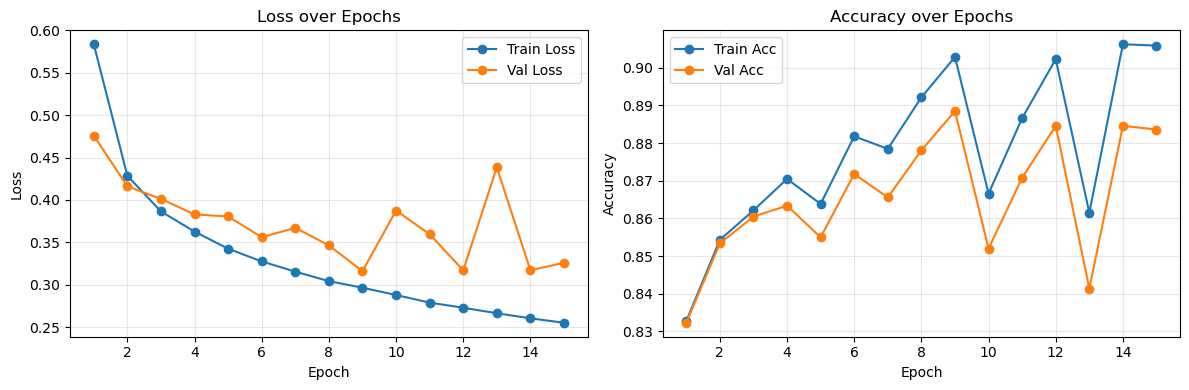


Total incorrect predictions: 1164 out of 10000


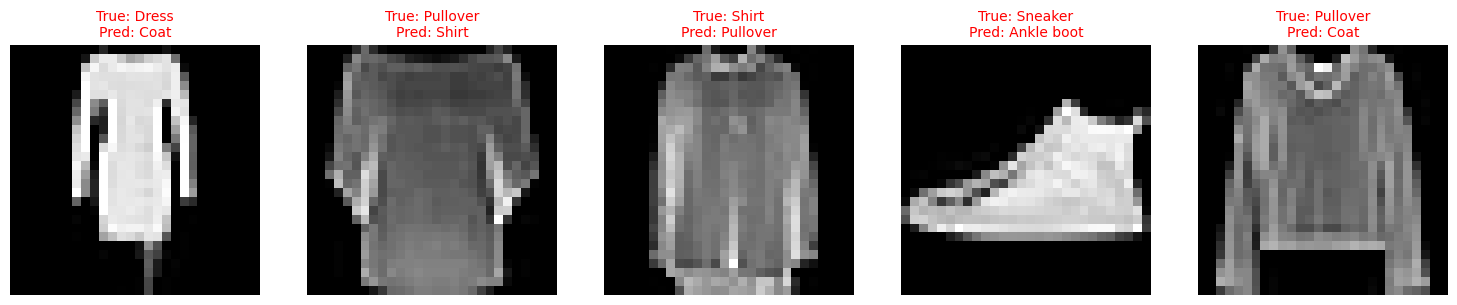

In [5]:
from minigrad.utils.visualization import plot_history, plot_misclassified

# 1. Plot History (Task point 9)
plot_history(history)

# 2. Plot Mistakes (Task point 12)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plot_misclassified(model, X_test, X_test_raw, y_test_raw, class_names)

--- EXPERIMENT 2: Deeper Network (ELU) ---
Deep Epoch 01/15 | Val Acc: 0.8184
Deep Epoch 02/15 | Val Acc: 0.8469
Deep Epoch 03/15 | Val Acc: 0.8150
Deep Epoch 04/15 | Val Acc: 0.8476
Deep Epoch 05/15 | Val Acc: 0.8390
Deep Epoch 06/15 | Val Acc: 0.8691
Deep Epoch 07/15 | Val Acc: 0.8681
Deep Epoch 08/15 | Val Acc: 0.8723
Deep Epoch 09/15 | Val Acc: 0.8694
Deep Epoch 10/15 | Val Acc: 0.8765
Deep Epoch 11/15 | Val Acc: 0.8718
Deep Epoch 12/15 | Val Acc: 0.8725
Deep Epoch 13/15 | Val Acc: 0.8844
Deep Epoch 14/15 | Val Acc: 0.8759
Deep Epoch 15/15 | Val Acc: 0.8800

Training time for Deep Model: 157.50 seconds
Inference time for 10,000 images: 0.2314 seconds


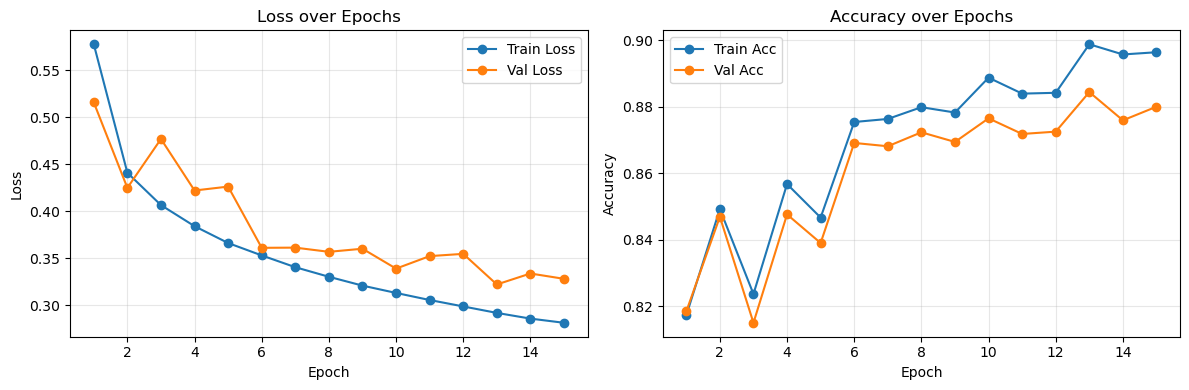

In [ ]:
import time
from minigrad.nn import ELU  

# ==========================================
# Experiment 2: Deeper network with ELU activation
# ==========================================

print("--- EXPERIMENT 2: Deeper Network (ELU) ---")

# Define a deeper model: 2 hidden layers
deep_model = Sequential(
    Linear(784, 256),
    ELU(alpha=1.0),
    Linear(256, 128),
    ELU(alpha=1.0),
    Linear(128, 10),
    Softmax()
)

# You can tune learning rate here
deep_optimizer = SGD(deep_model.parameters(), lr=0.05)

deep_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# 1. Measure Training Time
start_train_time = time.time()

for epoch in range(epochs): 
    train_loss = train_epoch(deep_model, X_train, y_train, categorical_cross_entropy, deep_optimizer, batch_size)
    _, train_acc = evaluate_model(deep_model, X_train, y_train, y_train_raw, categorical_cross_entropy, batch_size)
    val_loss, val_acc = evaluate_model(deep_model, X_test, y_test, y_test_raw, categorical_cross_entropy, batch_size)
    
    deep_history['train_loss'].append(train_loss)
    deep_history['val_loss'].append(val_loss)
    deep_history['train_acc'].append(train_acc)
    deep_history['val_acc'].append(val_acc)
    
    print(f"Deep Epoch {epoch+1:02d}/{epochs} | Val Acc: {val_acc:.4f}")

end_train_time = time.time()
print(f"\nTraining time for Deep Model: {end_train_time - start_train_time:.2f} seconds")

# 2. Measure Inference Time (Prediction time)
start_infer_time = time.time()
_ = deep_model(Tensor(X_test, requires_grad=False))
end_infer_time = time.time()

print(f"Inference time for 10,000 images: {end_infer_time - start_infer_time:.4f} seconds")

# Plot results for the deep model
plot_history(deep_history)

--- EXPERIMENT 3: Network with LeakyReLU ---
Leaky Epoch 01/15 | Val Acc: 0.8081
Leaky Epoch 02/15 | Val Acc: 0.8475
Leaky Epoch 03/15 | Val Acc: 0.8646
Leaky Epoch 04/15 | Val Acc: 0.8142
Leaky Epoch 05/15 | Val Acc: 0.8732
Leaky Epoch 06/15 | Val Acc: 0.8519
Leaky Epoch 07/15 | Val Acc: 0.8736
Leaky Epoch 08/15 | Val Acc: 0.8587
Leaky Epoch 09/15 | Val Acc: 0.8741
Leaky Epoch 10/15 | Val Acc: 0.8646
Leaky Epoch 11/15 | Val Acc: 0.8848
Leaky Epoch 12/15 | Val Acc: 0.8836
Leaky Epoch 13/15 | Val Acc: 0.8835
Leaky Epoch 14/15 | Val Acc: 0.8735
Leaky Epoch 15/15 | Val Acc: 0.8624

Training time for LeakyReLU Model: 58.02 seconds


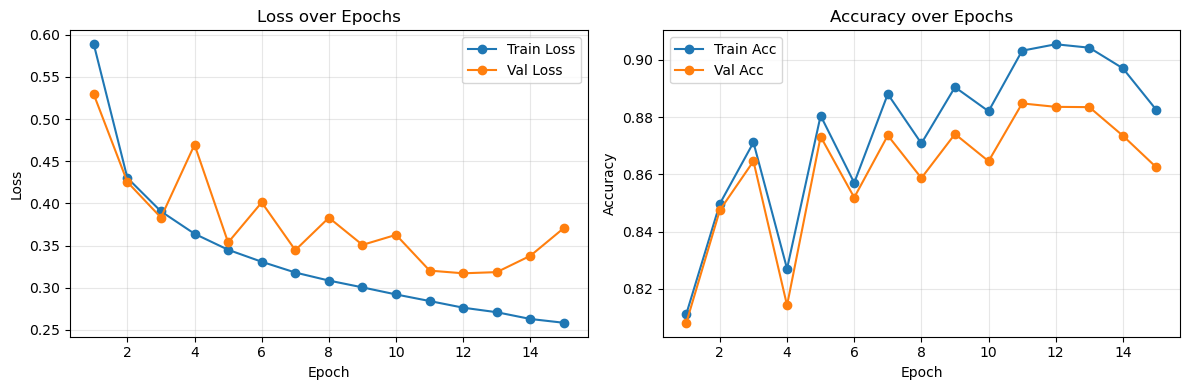

In [8]:
# ==========================================
# Experiment 3: Network with LeakyReLU activation
# ==========================================

print("--- EXPERIMENT 3: Network with LeakyReLU ---")
from minigrad.nn import LeakyReLU

# Define model with LeakyReLU (Task points 11)
leaky_model = Sequential(
    Linear(784, 128),
    LeakyReLU(alpha=0.01),
    Linear(128, 10),
    Softmax()
)

leaky_optimizer = SGD(leaky_model.parameters(), lr=0.1)

leaky_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# 1. Measure Training Time
start_train_time = time.time()

for epoch in range(epochs): 
    train_loss = train_epoch(leaky_model, X_train, y_train, categorical_cross_entropy, leaky_optimizer, batch_size)
    _, train_acc = evaluate_model(leaky_model, X_train, y_train, y_train_raw, categorical_cross_entropy, batch_size)
    val_loss, val_acc = evaluate_model(leaky_model, X_test, y_test, y_test_raw, categorical_cross_entropy, batch_size)
    
    leaky_history['train_loss'].append(train_loss)
    leaky_history['val_loss'].append(val_loss)
    leaky_history['train_acc'].append(train_acc)
    leaky_history['val_acc'].append(val_acc)
    
    print(f"Leaky Epoch {epoch+1:02d}/{epochs} | Val Acc: {val_acc:.4f}")

end_train_time = time.time()
print(f"\nTraining time for LeakyReLU Model: {end_train_time - start_train_time:.2f} seconds")

# 2. Plot results
plot_history(leaky_history)